In [ ]:
import os
try:
    BASE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE = os.getcwd()
from src.figures import save_figure

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
import seaborn as sns
from scipy.interpolate import griddata

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use(os.path.join(BASE,"..", "configs", "visualisations.mplstyle"))

from src.data_loader import _load_disaster_data
df = _load_disaster_data(BASE)

figure_path = os.path.join(BASE, '02_figures')
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

# VL 2: Statistical Learning

**Fig. 2.1** Feature and target relation

In [2]:
def _plot_scatter(df, x_axis, y_axis, fit_polyfit, n=2):
    mask = (df[x_axis] > 0) & (df[y_axis] > 0)
    x = np.log10(df.loc[mask, x_axis])
    y = np.log10(df.loc[mask, y_axis])

    plt.scatter(x, y, s=20, marker="o", alpha=1, edgecolors="w", linewidth=0.5)

    if fit_polyfit:
        coefficients = np.polyfit(x, y, n)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = poly(x_fit)
        plt.plot(
            x_fit, y_fit, color="red", linewidth=2, label=f"Polyfit ${n}^{{nd}}$ Degree"
        )

    plt.xticks(
        ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]),
        labels=["$10^0$", "$10^1$", "$10^2$", "$10^3$", "$10^4$", "$10^5$", "$10^6$"],
    )
    plt.yticks(
        ticks=np.log10([1e4, 1e6, 1e8, 1e10, 1e12]),
        labels=["$10^4$", "$10^6$", "$10^8$", "$10^{10}$", "$10^{12}$"],
    )
    plt.legend()

    plt.xlabel(f"{x_axis}")
    plt.ylabel(f"{y_axis}")
    plt.title(f"Scatterplot of {x_axis} vs. {y_axis}")
    save_figure(2, 1, "feature_target_relation", variant=f"{x_axis}_{y_axis}_deg{n}")
    plt.show()

Saved Fig. 2.1 -> 02_figures/2.1_feature_target_relation/2.1_feature_target_relation_No_Injured_Total_Damages_US_deg2.pdf


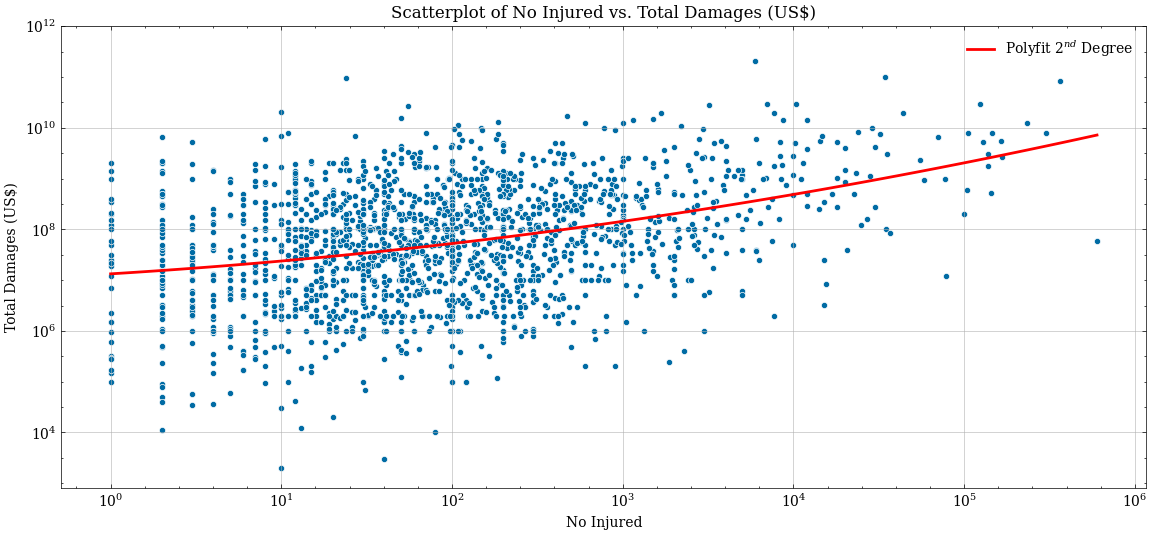

In [3]:
x_axis = 'No Injured'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis, y_axis, fit_polyfit)

Saved Fig. 2.1 -> 02_figures/2.1_feature_target_relation/2.1_feature_target_relation_Total_Deaths_Total_Damages_US_deg2.pdf


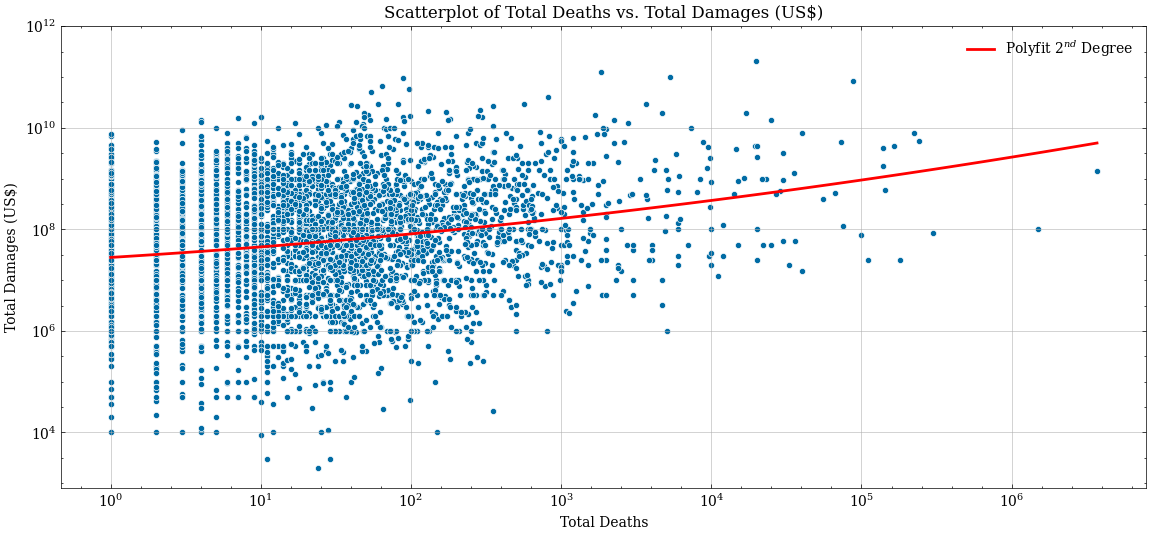

In [4]:
x_axis = 'Total Deaths'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis=x_axis, y_axis=y_axis, fit_polyfit=fit_polyfit)

Saved Fig. 2.1 -> 02_figures/2.1_feature_target_relation/2.1_feature_target_relation_No_Homeless_Total_Damages_US_deg2.pdf


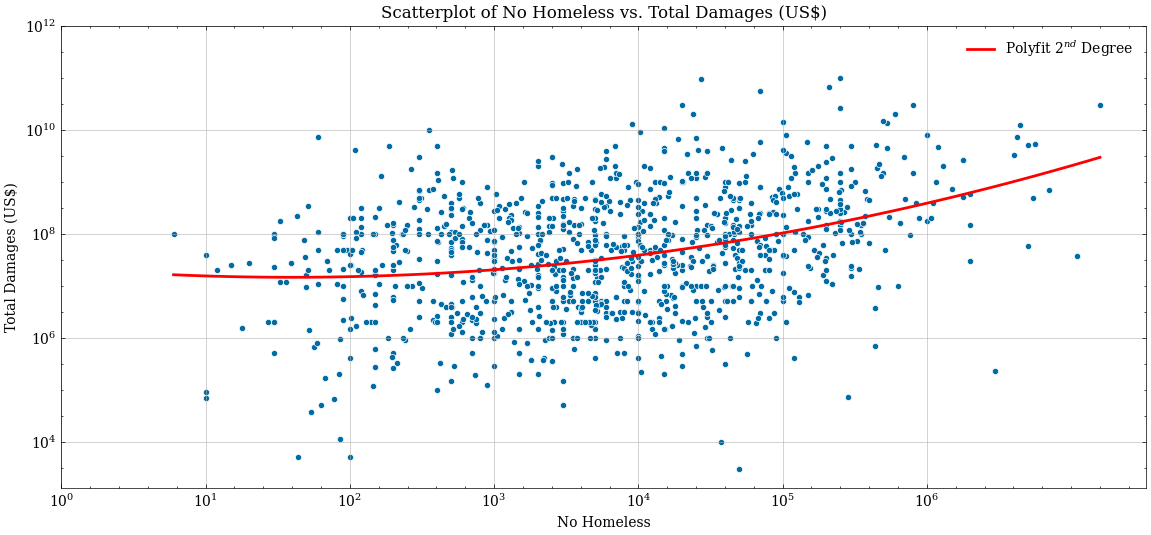

In [5]:
x_axis = 'No Homeless'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis=x_axis, y_axis=y_axis, fit_polyfit=fit_polyfit)

**Fig. 2.2** Function surface

In [ ]:
def _plot_3D_surface(elev=20, azim=-45, grid_size=100):
    x_axis = "No Injured"
    y_axis = "Total Deaths"
    z_axis = "Total Damages (US$)"

    subset_df = df[(df[x_axis] > 0) & (df[y_axis] > 0) & (df[z_axis] > 0)]

    x = np.log10(subset_df[x_axis])
    y = np.log10(subset_df[y_axis])
    z = np.log10(subset_df[z_axis])

    xi = np.linspace(x.min(), x.max(), grid_size)
    yi = np.linspace(y.min(), y.max(), grid_size)
    X, Y = np.meshgrid(xi, yi)

    Z = griddata((x, y), z, (X, Y), method="linear")

    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="coolwarm")
    ax.set_xticks(
        ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]),
        labels=["$10^0$", "$10^1$", "$10^2$", "$10^3$", "$10^4$", "$10^5$", "$10^6$"],
    )
    ax.set_yticks(
        ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]),
        labels=["$10^0$", "$10^1$", "$10^2$", "$10^3$", "$10^4$", "$10^5$", "$10^6$"],
    )
    ax.set_zticks(
        ticks=np.log10([1e4, 1e6, 1e8, 1e10]),
        labels=["$10^4$", "$10^6$", "$10^8$", "$10^{10}$"],
    )
    ax.set_zlim(4, 11)
    ax.set_xlabel(f"{x_axis}")
    ax.set_ylabel(f"{y_axis}")
    ax.set_zlabel(f"{z_axis}")
    ax.view_init(elev=elev, azim=azim, roll=0)
    ax.set_box_aspect(None, zoom=0.8)
    save_figure(
        2, 2, "function_surface", variant=f"{x_axis}_{y_axis}_{z_axis}_grid{grid_size}"
    )
    plt.show()

Saved Fig. 2.2 -> 02_figures/2.2_function_surface/2.2_function_surface_No_Injured_Total_Deaths_Total_Damages_US_grid100.pdf


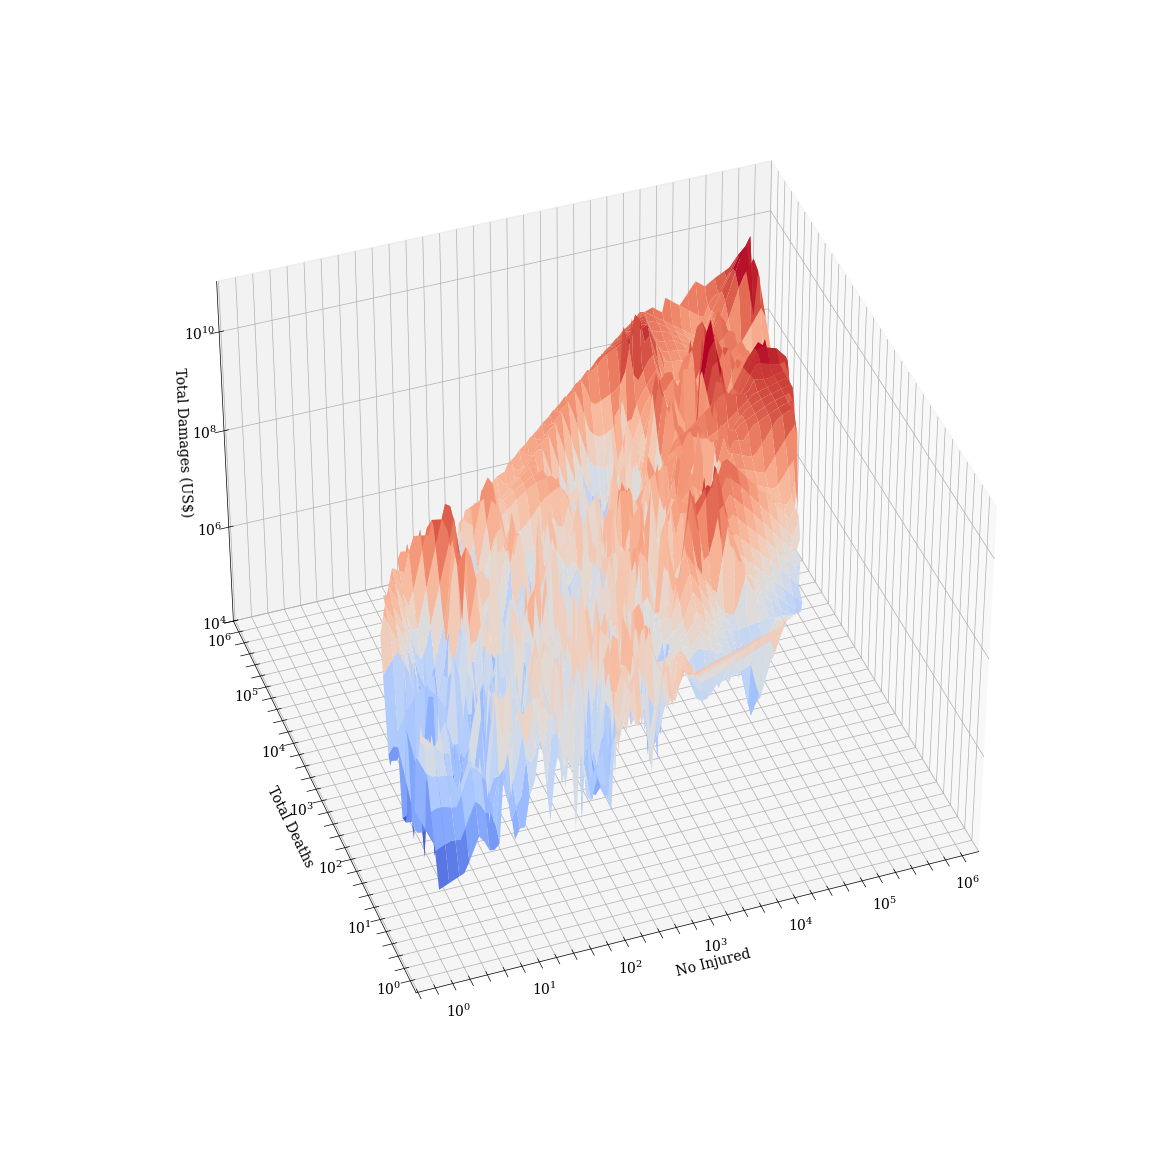

In [7]:
_plot_3D_surface(elev=40, azim=-110, grid_size=100)


Saved Fig. 2.2 -> 02_figures/2.2_function_surface/2.2_function_surface_No_Injured_Total_Deaths_Total_Damages_US_grid10.pdf


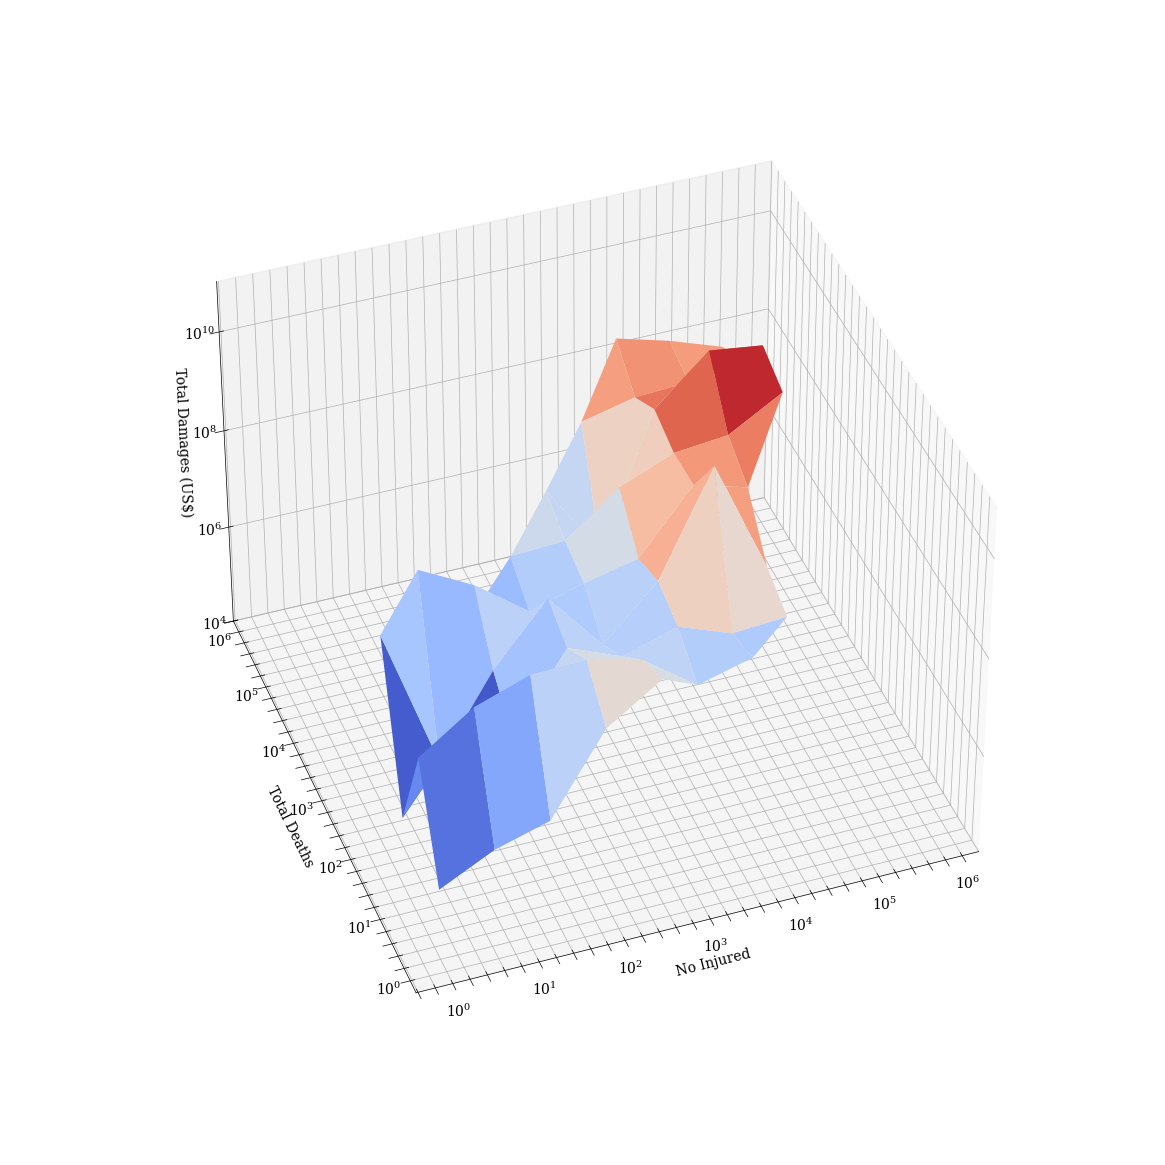

In [8]:
_plot_3D_surface(elev=40, azim=-110, grid_size=10)


Saved Fig. 2.2 -> 02_figures/2.2_function_surface/2.2_function_surface_No_Injured_Total_Deaths_Total_Damages_US_grid20.pdf


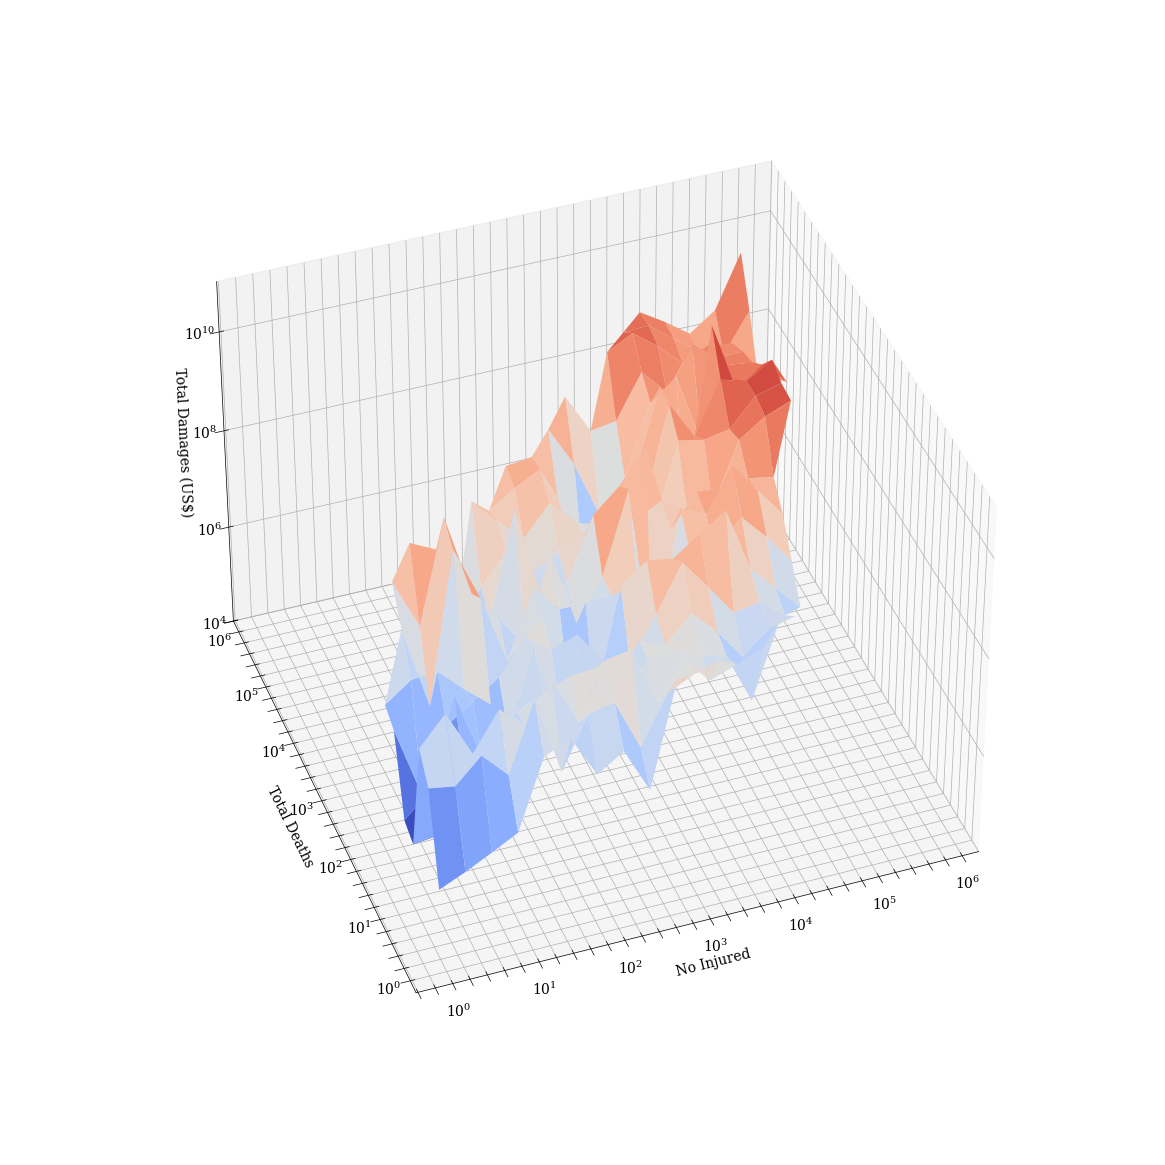

In [9]:
_plot_3D_surface(elev=40, azim=-110, grid_size=20)


Saved Fig. 2.2 -> 02_figures/2.2_function_surface/2.2_function_surface_No_Injured_Total_Deaths_Total_Damages_US_grid200.pdf


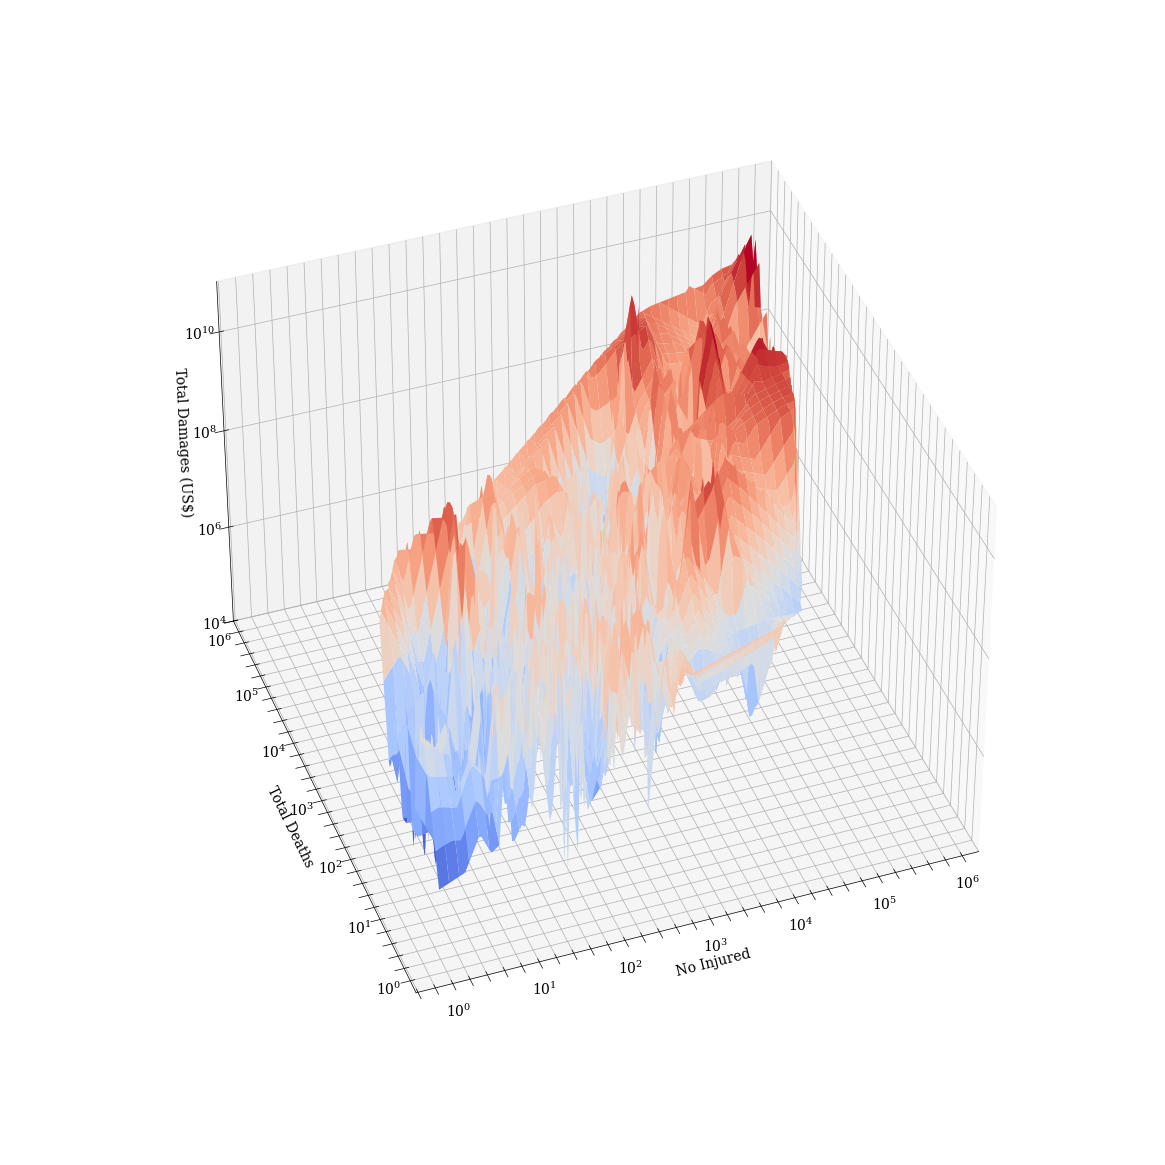

In [10]:
_plot_3D_surface(elev=40, azim=-110, grid_size=200)


**Fig. 2.3** Joint distribution heatmap

/var/folders/ct/qpfxjbdn1xx4fvb2v099sg_00000gn/T/ipykernel_29393/2493899849.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["year"] = df_subset["date"].dt.year
/var/folders/ct/qpfxjbdn1xx4fvb2v099sg_00000gn/T/ipykernel_29393/2493899849.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["month"] = df_subset["date"].dt.month


Saved Fig. 2.3 -> 02_figures/2.3_joint_distribution/2.3_joint_distribution_Riverine_flood_Germany.pdf


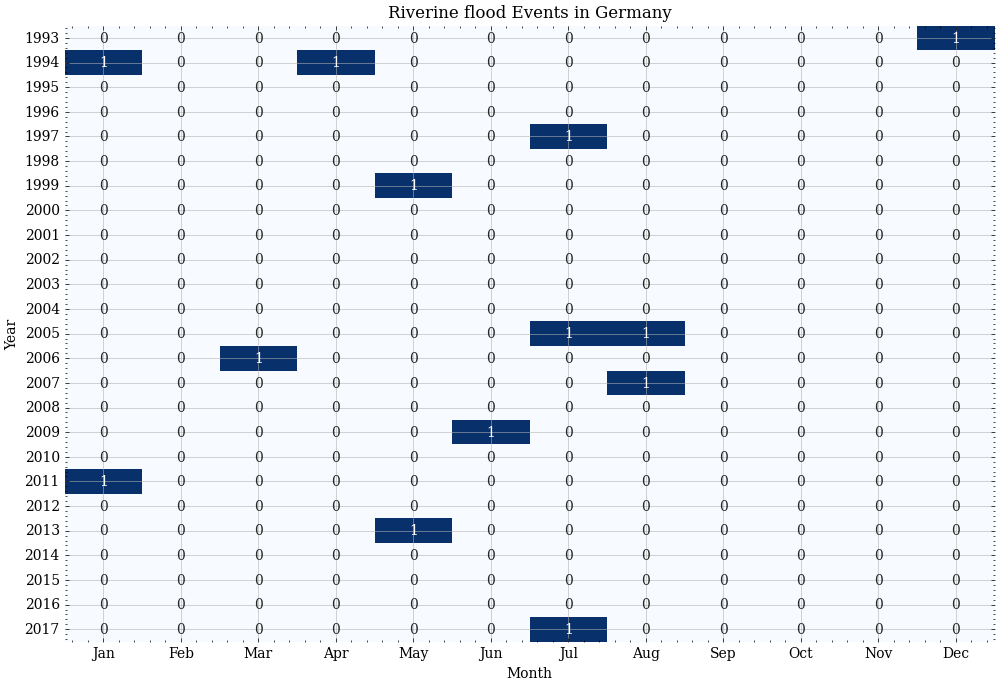

In [11]:
country_focus = "Germany"
disaster_event_focus = "Riverine flood"

df_subset = df[
    (df["Disaster Subtype"] == disaster_event_focus)
    & (df["Country"] == country_focus)
]
df_subset["year"] = df_subset["date"].dt.year
df_subset["month"] = df_subset["date"].dt.month

df_grouped = df_subset.groupby(["year", "month"]).size().reset_index(name="count")

all_years = range(df_grouped["year"].min(), df_grouped["year"].max() + 1)
all_months = range(1, 13)
all_combinations = pd.MultiIndex.from_product(
    [all_years, all_months], names=["year", "month"]
)
df_grouped = (
    df_grouped.set_index(["year", "month"])
    .reindex(all_combinations, fill_value=0)
    .reset_index()
)


plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    df_grouped.pivot(index="year", columns="month", values="count"),
    cmap="Blues",
    annot=True,
)
plt.title(f"{disaster_event_focus} Events in {country_focus}")
cb = ax.collections[0].colorbar
cb.remove()

month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
ax.set_xticklabels(month_names)

plt.xlabel("Month")
plt.ylabel("Year")
save_figure(2, 3, 'joint_distribution', variant=f'{disaster_event_focus}_{country_focus}')
plt.show()

**Fig. 2.4** Regression error metrics

MAE: 0.861279520465127, MSE: 1.1397927412374464, RMSE: 1.067610762983142


<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:69: SyntaxWarning: invalid escape sequence '\h'
<>:67: SyntaxWarning: invalid escape sequence '\h'
<>:69: SyntaxWarning: invalid escape sequence '\h'
/var/folders/ct/qpfxjbdn1xx4fvb2v099sg_00000gn/T/ipykernel_29393/3467373961.py:67: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel("$y - \hat{y}$")
/var/folders/ct/qpfxjbdn1xx4fvb2v099sg_00000gn/T/ipykernel_29393/3467373961.py:69: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel("$(y - \hat{y})^2$")


Saved Fig. 2.4 -> 02_figures/2.4_regression_metrics/2.4_regression_metrics_No_Homeless_Total_Damages_US.pdf


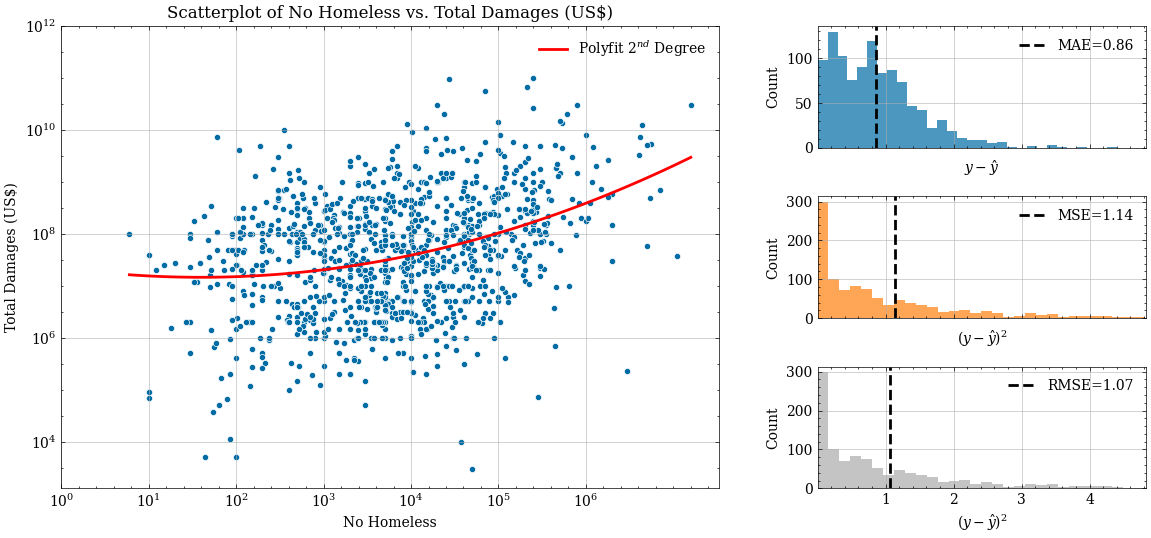

In [12]:
def _plot_scatter_with_error_histograms(df, x_axis, y_axis, fit_polyfit):
    mask = (df[x_axis] > 0) & (df[y_axis] > 0)
    x = np.log10(df.loc[mask, x_axis])
    y = np.log10(df.loc[mask, y_axis])

    fig = plt.figure()
    gs = fig.add_gridspec(3, 2, width_ratios=[2, 1], hspace=0.4)

    ax_scatter = fig.add_subplot(gs[:, 0])
    ax_scatter.scatter(x, y, s=20, marker="o", alpha=1, edgecolors="w", linewidth=0.5)
    if fit_polyfit:
        n = 2
        coefficients = np.polyfit(x, y, n)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = poly(x_fit)
        ax_scatter.plot(
            x_fit, y_fit, color="red", linewidth=2, label=f"Polyfit ${n}^{{nd}}$ Degree"
        )
        y_pred = poly(x)
        residuals = y - y_pred
        mae = np.abs(residuals)
        mse = residuals**2
        rmse = mse

        sk_mae = mean_absolute_error(y, y_pred)
        sk_mse = mean_squared_error(y, y_pred)
        sk_rmse = root_mean_squared_error(y, y_pred)
        print(f"MAE: {sk_mae}, MSE: {sk_mse}, RMSE: {sk_rmse}")
    else:
        mae = mse = rmse = np.zeros_like(y)

    ax_scatter.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]))
    ax_scatter.set_xticklabels(
        ["$10^0$", "$10^1$", "$10^2$", "$10^3$", "$10^4$", "$10^5$", "$10^6$"]
    )
    ax_scatter.set_yticks(np.log10([1e4, 1e6, 1e8, 1e10, 1e12]))
    ax_scatter.set_yticklabels(["$10^4$", "$10^6$", "$10^8$", "$10^{10}$", "$10^{12}$"])
    ax_scatter.legend()
    ax_scatter.set_xlabel(f"{x_axis}")
    ax_scatter.set_ylabel(f"{y_axis}")
    ax_scatter.set_title(f"Scatterplot of {x_axis} vs. {y_axis}")

    metrics = [mae, mse, rmse]
    titles = ["MAE", "MSE", "RMSE"]
    defined_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    all_errors = np.concatenate(metrics)
    x_min, x_max = all_errors.min(), all_errors.max() * 0.25

    for i, (err, title, color) in enumerate(zip(metrics, titles, defined_colors)):
        ax = fig.add_subplot(gs[i, 1])
        visual_err = err[(err > x_min) & (err < x_max)]
        ax.hist(visual_err, bins=30, alpha=0.7, color=color)
        metric_value = err.mean()
        if title == "RMSE":
            metric_value = np.sqrt(np.mean(err))
        ax.axvline(
            metric_value,
            color="k",
            linestyle="dashed",
            linewidth=2,
            label=f"{title}={metric_value:.2f}",
        )
        ax.set_xlim(x_min, x_max)
        if i == 0:
            ax.set_xlabel("$y - \hat{y}$")
        else:
            ax.set_xlabel("$(y - \hat{y})^2$")
        ax.set_ylabel("Count")
        ax.legend()
        if i < 2:
            ax.tick_params(labelbottom=False)

    save_figure(2, 4, "regression_metrics", variant=f"{x_axis}_{y_axis}")
    plt.show()


_plot_scatter_with_error_histograms(
    df, x_axis="No Homeless", y_axis="Total Damages (US$)", fit_polyfit=True
)

**Fig. 2.5** Train, validation and test split

Saved Fig. 2.5 -> 02_figures/2.5_train_test_split/2.5_train_test_split_No_Homeless_Total_Damages_US_train0.8_val0.1.pdf


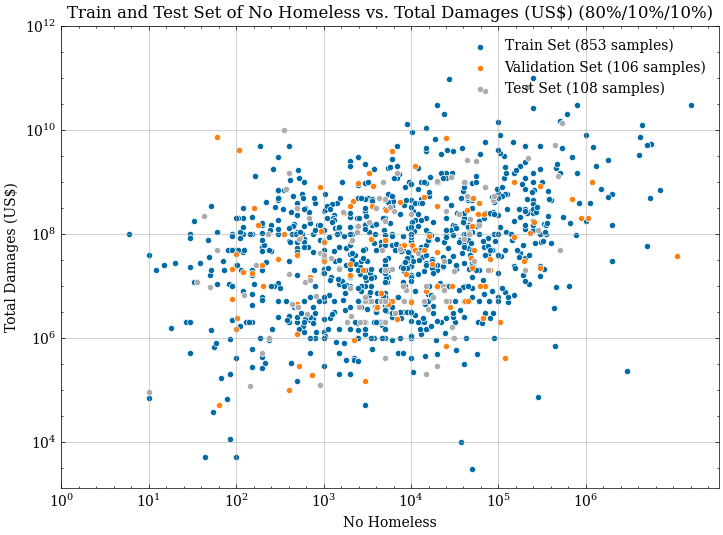

In [13]:
def _plot_scatter_with_train_test_split(
    df,
    x_axis="No Homeless",
    y_axis="Total Damages (US$)",
    train_ratio=0.8,
    val_ratio=0.1,
):
    mask = (df[x_axis] > 0) & (df[y_axis] > 0)
    x = np.log10(df.loc[mask, x_axis])
    y = np.log10(df.loc[mask, y_axis])
    test_ratio = 1 - train_ratio - val_ratio

    np.random.seed(0)
    indices = np.random.permutation(len(x))
    train_size = int(len(x) * train_ratio)
    val_size = int(len(x) * val_ratio)
    test_size = len(x) - train_size - val_size

    train_indices = indices[:train_size]
    val_indices = indices[train_size : train_size + val_size]
    test_indices = indices[train_size + val_size :]

    x_train = x.iloc[train_indices]
    y_train = y.iloc[train_indices]
    x_val = x.iloc[val_indices]
    y_val = y.iloc[val_indices]
    x_test = x.iloc[test_indices]
    y_test = y.iloc[test_indices]

    fig = plt.figure()
    gs = fig.add_gridspec(3, 2, width_ratios=[2, 1], hspace=0.4)

    # Scatter and fitted poly
    ax_scatter = fig.add_subplot(gs[:, 0])
    ax_scatter.scatter(
        x_train,
        y_train,
        s=20,
        marker="o",
        alpha=1,
        edgecolors="w",
        linewidth=0.5,
        label=f"Train Set ({x_train.shape[0]} samples)",
    )
    ax_scatter.scatter(
        x_val,
        y_val,
        s=20,
        marker="o",
        alpha=1,
        edgecolors="w",
        linewidth=0.5,
        label=f"Validation Set ({x_val.shape[0]} samples)",
    )
    ax_scatter.scatter(
        x_test,
        y_test,
        s=20,
        marker="o",
        alpha=1,
        edgecolors="w",
        linewidth=0.5,
        label=f"Test Set ({x_test.shape[0]} samples)",
    )
    ax_scatter.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]))
    ax_scatter.set_xticklabels(
        ["$10^0$", "$10^1$", "$10^2$", "$10^3$", "$10^4$", "$10^5$", "$10^6$"]
    )
    ax_scatter.set_yticks(np.log10([1e4, 1e6, 1e8, 1e10, 1e12]))
    ax_scatter.set_yticklabels(["$10^4$", "$10^6$", "$10^8$", "$10^{10}$", "$10^{12}$"])
    ax_scatter.legend(loc="upper right", bbox_to_anchor=(1.0, 1))
    ax_scatter.set_xlabel(f"{x_axis}")
    ax_scatter.set_ylabel(f"{y_axis}")
    ax_scatter.set_title(
        f"Train and Test Set of {x_axis} vs. {y_axis} ({train_ratio*100:.0f}%/{(val_ratio)*100:.0f}%/{(test_ratio)*100:.0f}%)"
    )
    save_figure(
        2,
        5,
        "train_test_split",
        variant=f"{x_axis}_{y_axis}_train{train_ratio}_val{val_ratio}",
    )
    plt.show()


_plot_scatter_with_train_test_split(
    df,
    x_axis="No Homeless",
    y_axis="Total Damages (US$)",
    train_ratio=0.8,
    val_ratio=0.1,
)

Saved Fig. 2.5 -> 02_figures/2.5_train_test_split/2.5_train_test_split_No_Homeless_Total_Damages_US_train0.98_val0.01.pdf


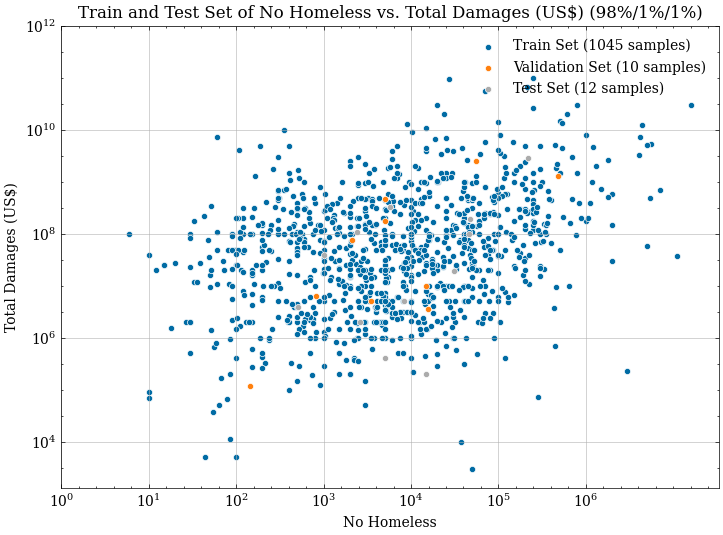

In [14]:
_plot_scatter_with_train_test_split(df, x_axis='No Homeless', y_axis='Total Damages (US$)', train_ratio=0.98, val_ratio=0.01)


Saved Fig. 2.5 -> 02_figures/2.5_train_test_split/2.5_train_test_split_No_Homeless_Total_Damages_US_train0.5_val0.25.pdf


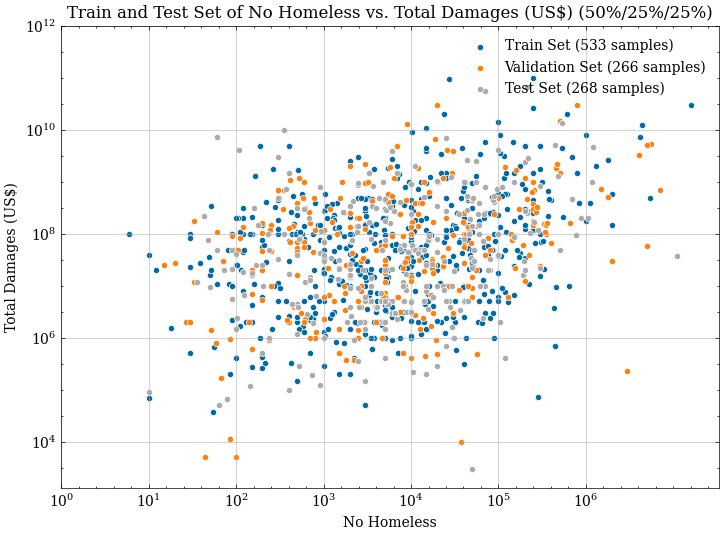

In [15]:
_plot_scatter_with_train_test_split(df, x_axis='No Homeless', y_axis='Total Damages (US$)', train_ratio=0.5, val_ratio=0.25)


Saved Fig. 2.5 -> 02_figures/2.5_train_test_split/2.5_train_test_split_No_Homeless_Total_Damages_US_train0.25_val0.5.pdf


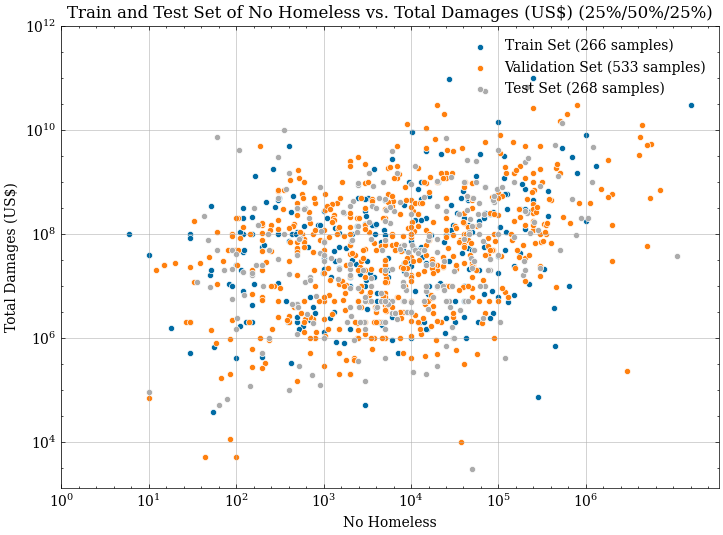

In [16]:
_plot_scatter_with_train_test_split(df, x_axis='No Homeless', y_axis='Total Damages (US$)', train_ratio=0.25, val_ratio=0.5)
